# **Dataset:** ICBHI 2017 Respiratory Sound Database
### **Source:** https://bhichallenge.med.auth.gr/ICBHI_2017_Challenge
### **Total Files:** 920 recordings
### **Patients:** 126

## 1. Setup and Imports

In [1]:
import os
import sys
import librosa
import librosa.display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# Add project root to path
sys.path.append('..')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Define Path

In [2]:
# Path to ICBHI dataset
ICBHI_PATH = Path("../sound_data/icbhi")

print(f"ICBHI folder exists: {ICBHI_PATH.exists()}")
print(f"Contents: {len(list(ICBHI_PATH.glob('*')))} files total")

ICBHI folder exists: True
Contents: 1843 files total


## 3. Separate Audio and Annotation Files

In [6]:
# Get all .wav files (audio)
audio_files = list(ICBHI_PATH.glob("*.wav"))
print(f"Audio files (.wav): {len(audio_files)}")

# Get all .txt files (annotations)
annotation_files = list(ICBHI_PATH.glob("*.txt"))
print(f"Annotation files (.txt): {len(annotation_files)}")

# Show first 5 of each
print("\nSample audio files:")
for f in audio_files[:5]:
    print(f"  - {f.name}")

print("\nSample annotation files:")
for f in annotation_files[:5]:
    print(f"  - {f.name}")
    
# Match Checking
audio_names = {f.stem for f in audio_files}
annotation_names = {f.stem for f in annotation_files}
common_names = audio_names.intersection(annotation_names)

print(f"\n Files with both .wav and .txt: {len(common_names)} out of {len(audio_files)}")

if len(common_names) < len(audio_files):
    print(f"{len(audio_files) - len(common_names)} audio files missing annotations")

Audio files (.wav): 920
Annotation files (.txt): 922

Sample audio files:
  - 101_1b1_Al_sc_Meditron.wav
  - 101_1b1_Pr_sc_Meditron.wav
  - 102_1b1_Ar_sc_Meditron.wav
  - 103_2b2_Ar_mc_LittC2SE.wav
  - 104_1b1_Al_sc_Litt3200.wav

Sample annotation files:
  - 101_1b1_Al_sc_Meditron.txt
  - 101_1b1_Pr_sc_Meditron.txt
  - 102_1b1_Ar_sc_Meditron.txt
  - 103_2b2_Ar_mc_LittC2SE.txt
  - 104_1b1_Al_sc_Litt3200.txt

 Files with both .wav and .txt: 920 out of 920


## 4. Parse Filename Information

### Filename format: `[patient]_[recording]_[location]_[mode]_[equipment].wav`

### **Example:** `101_1b1_Al_sc_Meditron.wav`
#### - 101 = patient ID
#### - 1b1 = recording index
#### - Al = anterior left chest location
#### - sc = single channel
#### - Meditron = recording equipment

### **Chest location** (Trachea (Tc), {Anterior (A), Posterior (P), Lateral (L)} {left (l), right (r)})
#### Ar- Anterior right
#### Al - Anterior left
#### Pl- Posterior left
#### Pr - Posterior right
#### Tc- Trachea
#### Lr - Lateral right
#### Ll - Lateral left


Parsed 920 files
Total unique patients: 126


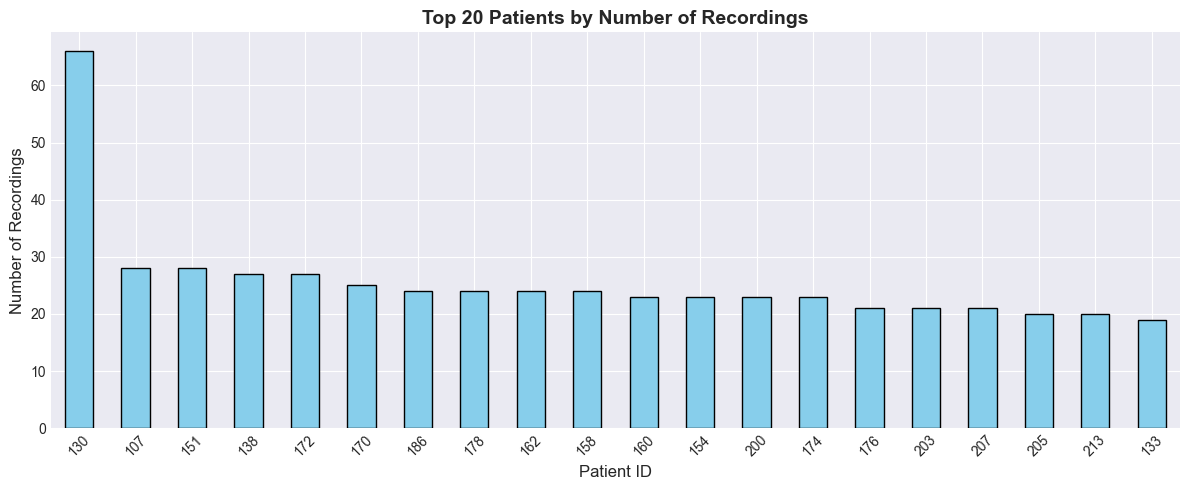

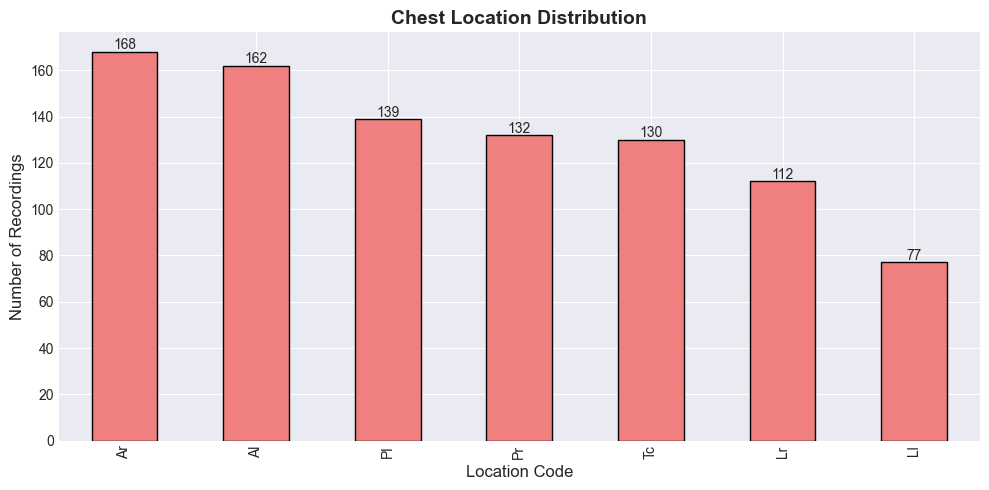

In [7]:
# Parse filenames into components
file_info = []
for f in audio_files:
    parts = f.stem.split('_')
    if len(parts) >= 4:
        info = {
            'filename': f.name,
            'patient_id': parts[0],
            'recording_id': parts[1],
            'chest_location': parts[2],
            'recording_mode': parts[3] if len(parts) > 3 else 'unknown',
            'equipment': parts[4] if len(parts) > 4 else 'unknown',
            'has_annotation': f.stem in annotation_names,
            'full_path': str(f)
        }
        file_info.append(info)

df_files = pd.DataFrame(file_info)
print(f"Parsed {len(df_files)} files")
df_files.head()

# Check patient distribution
n_patients = df_files['patient_id'].nunique()
print(f"Total unique patients: {n_patients}")

# Recordings per patient
plt.figure(figsize=(12, 5))
recordings_per_patient = df_files['patient_id'].value_counts()
recordings_per_patient.head(20).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 20 Patients by Number of Recordings', fontsize=14, fontweight='bold')
plt.xlabel('Patient ID', fontsize=12)
plt.ylabel('Number of Recordings', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Check chest location distribution
plt.figure(figsize=(10, 5))
location_counts = df_files['chest_location'].value_counts()
ax = location_counts.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Chest Location Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Location Code', fontsize=12)
plt.ylabel('Number of Recordings', fontsize=12)

for i, v in enumerate(location_counts.values):
    ax.text(i, v + 1, str(v), ha='center')
    
plt.tight_layout()
plt.show()

## 5. Explore Annotation Files

In [8]:
# Function to parse ICBHI annotation file
def parse_annotation(file_path):
    """Parse ICBHI annotation file"""
    annotations = []
    try:
        with open(file_path, 'r') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) >= 4:
                    anno = {
                        'start': float(parts[0]),
                        'end': float(parts[1]),
                        'crackles': int(parts[2]),
                        'wheezes': int(parts[3]),
                        'annotation_file': file_path.name
                    }
                    annotations.append(anno)
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
    return annotations

# Sample annotation file
if annotation_files:
    sample_anno = annotation_files[0]
    print(f"📝 Sample annotation file: {sample_anno.name}")
    
    annotations = parse_annotation(sample_anno)
    df_sample_anno = pd.DataFrame(annotations)
    
    print(f"\nNumber of events: {len(df_sample_anno)}")
    print("\nFirst few events:")
    print(df_sample_anno.head())
    
    # Count sound types
    df_sample_anno['sound_type'] = 'normal'
    df_sample_anno.loc[df_sample_anno['crackles'] == 1, 'sound_type'] = 'crackles'
    df_sample_anno.loc[df_sample_anno['wheezes'] == 1, 'sound_type'] = 'wheezes'
    df_sample_anno.loc[(df_sample_anno['crackles'] == 1) & (df_sample_anno['wheezes'] == 1), 'sound_type'] = 'both'
    
    print("\nSound type distribution in this file:")
    print(df_sample_anno['sound_type'].value_counts())

📝 Sample annotation file: 101_1b1_Al_sc_Meditron.txt

Number of events: 12

First few events:
   start    end  crackles  wheezes             annotation_file
0  0.036  0.579         0        0  101_1b1_Al_sc_Meditron.txt
1  0.579  2.450         0        0  101_1b1_Al_sc_Meditron.txt
2  2.450  3.893         0        0  101_1b1_Al_sc_Meditron.txt
3  3.893  5.793         0        0  101_1b1_Al_sc_Meditron.txt
4  5.793  7.521         0        0  101_1b1_Al_sc_Meditron.txt

Sound type distribution in this file:
sound_type
normal    12
Name: count, dtype: int64


## 6. Audio Analysis - Basic Statistics

Extracting features from 100 files...
Successfully extracted features from 100 files


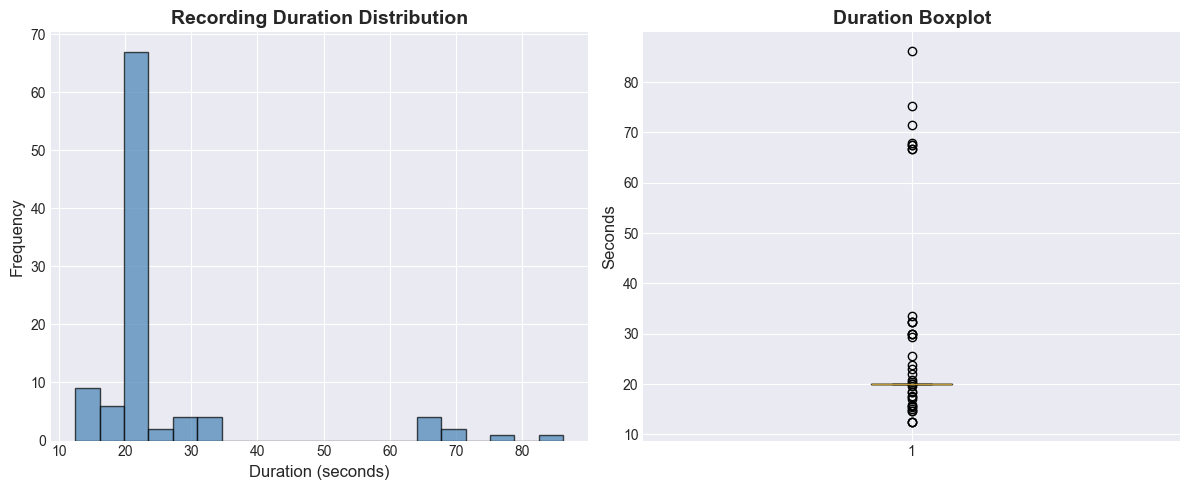


 Duration Statistics:
  Mean: 24.52 seconds
  Median: 20.00 seconds
  Min: 12.46 seconds
  Max: 86.20 seconds
  Std: 14.43 seconds


<Figure size 1000x500 with 0 Axes>

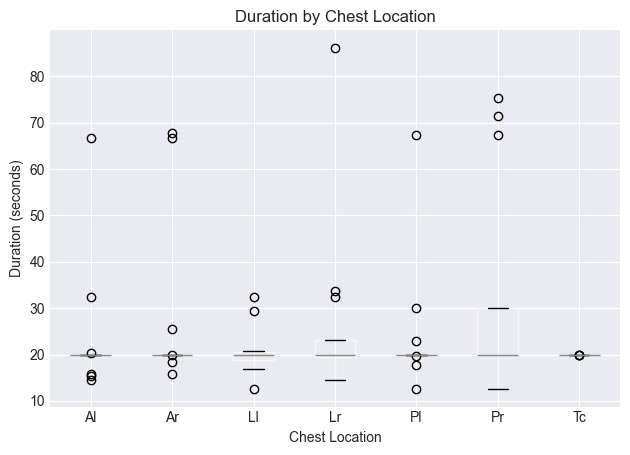

In [9]:
# Function to extract basic audio features
def extract_basic_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)
        duration = len(y) / sr
        
        features = {
            'filename': file_path.name,
            'duration': duration,
            'sample_rate': sr,
            'samples': len(y),
            'patient_id': file_path.stem.split('_')[0],
            'chest_location': file_path.stem.split('_')[2] if len(file_path.stem.split('_')) > 2 else 'unknown'
        }
        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Extract features from a sample of 100 audio files
sample_size = min(100, len(audio_files))
sample_files = audio_files[:sample_size]

print(f"Extracting features from {sample_size} files...")
audio_stats = []
for f in sample_files:
    stats = extract_basic_features(f)
    if stats:
        audio_stats.append(stats)

df_audio_stats = pd.DataFrame(audio_stats)
print(f"Successfully extracted features from {len(df_audio_stats)} files")
df_audio_stats.head()

# Duration distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_audio_stats['duration'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Recording Duration Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Duration (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
plt.boxplot(df_audio_stats['duration'])
plt.title('Duration Boxplot', fontsize=14, fontweight='bold')
plt.ylabel('Seconds', fontsize=12)

plt.tight_layout()
plt.show()

# Duration statistics
# Duration statistics
print("\n Duration Statistics:")
print(f"  Mean: {df_audio_stats['duration'].mean():.2f} seconds")
print(f"  Median: {df_audio_stats['duration'].median():.2f} seconds")
print(f"  Min: {df_audio_stats['duration'].min():.2f} seconds")
print(f"  Max: {df_audio_stats['duration'].max():.2f} seconds")
print(f"  Std: {df_audio_stats['duration'].std():.2f} seconds")

# Duration by chest location
plt.figure(figsize=(10, 5))
df_audio_stats.boxplot(column='duration', by='chest_location')
plt.title('Duration by Chest Location')
plt.suptitle('')
plt.xlabel('Chest Location')
plt.ylabel('Duration (seconds)')
plt.tight_layout()
plt.show()


## 7. Audio Analysis - Waveform Visualization

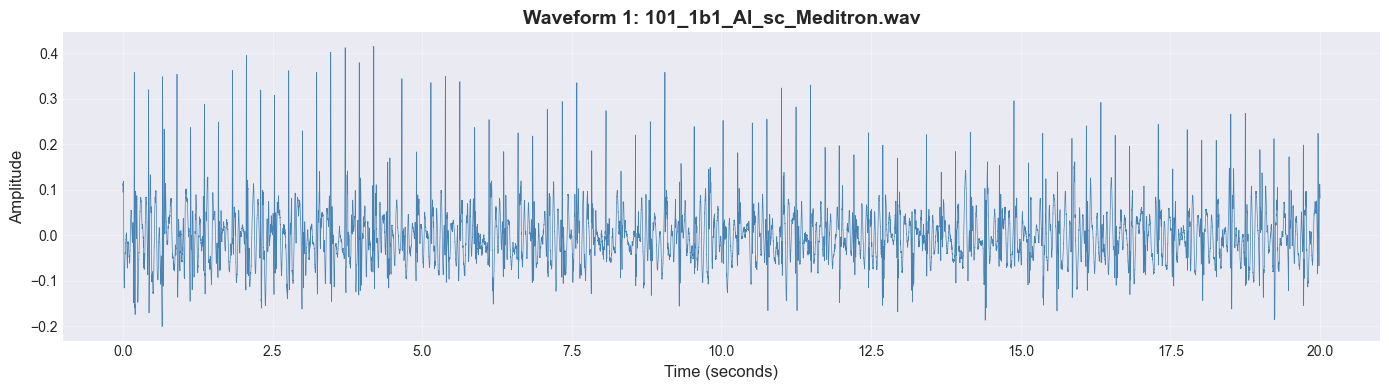

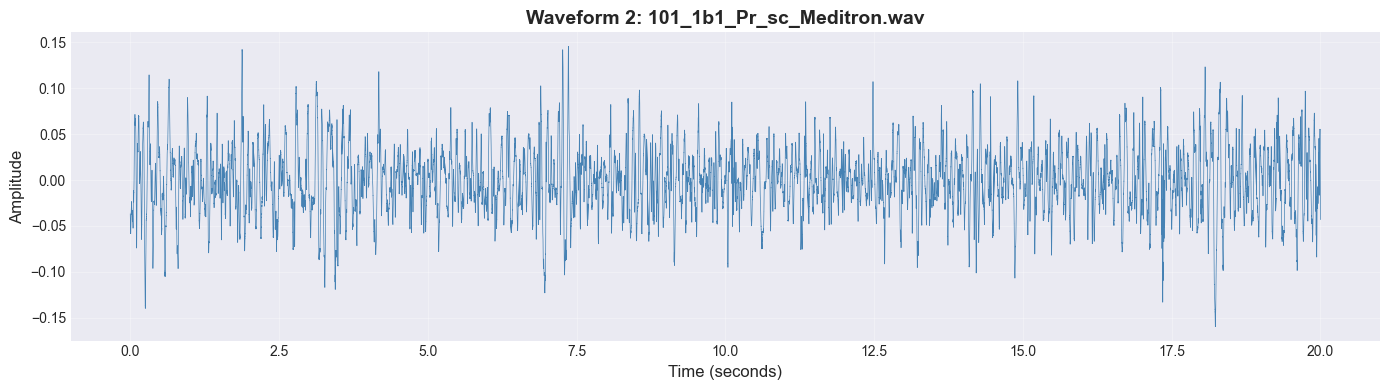

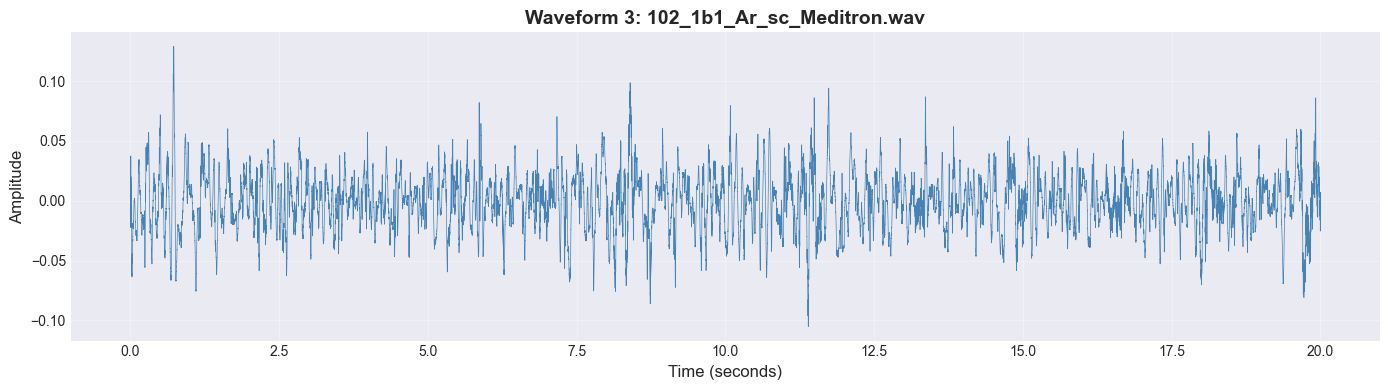

In [11]:
# Function to plot waveform
def plot_waveform(file_path, title=None):
    y, sr = librosa.load(file_path, sr=None)
    duration = len(y) / sr
    
    plt.figure(figsize=(14, 4))
    times = np.linspace(0, duration, len(y))
    plt.plot(times, y, color='steelblue', linewidth=0.5)
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Amplitude', fontsize=12)
    
    if title:
        plt.title(title, fontsize=14, fontweight='bold')
    else:
        plt.title(f'Waveform - {file_path.name}', fontsize=14, fontweight='bold')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    return y, sr

# 3 sample waveforms
sample_waveforms = audio_files[:3]

for i, f in enumerate(sample_waveforms):
    y, sr = plot_waveform(f, f"Waveform {i+1}: {f.name}")
    plt.show()

 ## 8. Audio Analysis - Spectrogram Visualization

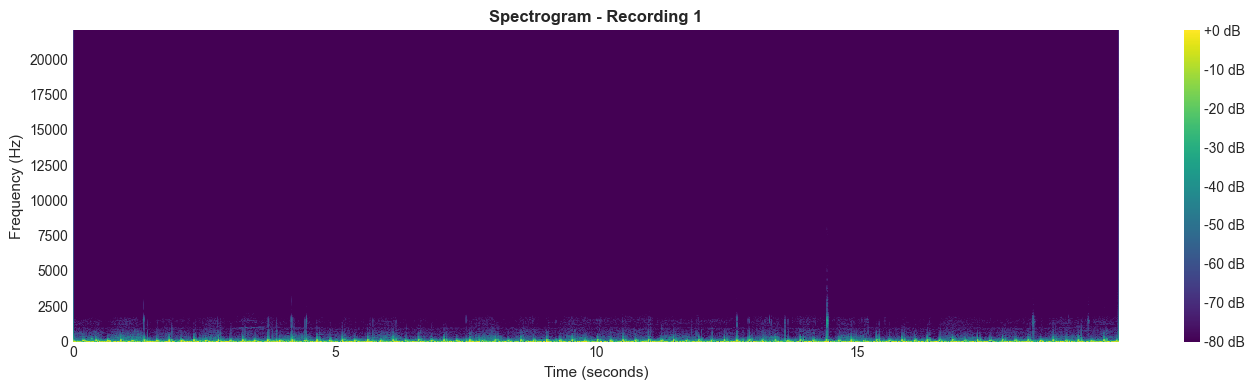

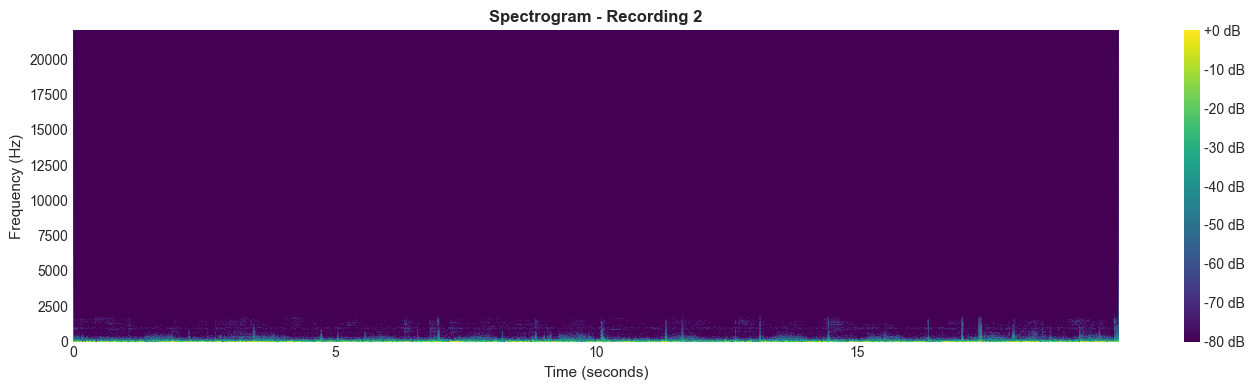

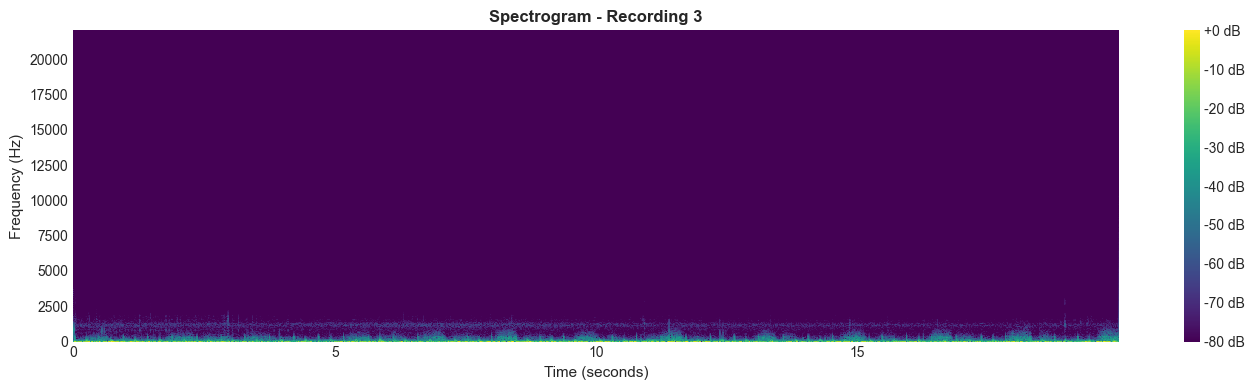

In [13]:
# Function to plot spectrogram
def plot_spectrogram(file_path, title=None):
    y, sr = librosa.load(file_path, sr=None)
    
    plt.figure(figsize=(14, 4))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    
    if title:
        plt.title(f'Spectrogram - {title}', fontsize=12, fontweight='bold')
    else:
        plt.title(f'Spectrogram - {file_path.name}', fontsize=12, fontweight='bold')
    
    plt.xlabel('Time (seconds)', fontsize=11)
    plt.ylabel('Frequency (Hz)', fontsize=11)
    plt.tight_layout()

# %%
# Plot spectrograms for the same 3 samples
for i, f in enumerate(audio_files[:3]):
    plot_spectrogram(f, f"Recording {i+1}")
    plt.show()

## 9. Mel-Frequency Cepstral Coefficients (MFCCs) Feature Extraction

MFCC shape for 101_1b1_Al_sc_Meditron.wav:
  - 13 MFCC coefficients
  - 1723 time frames


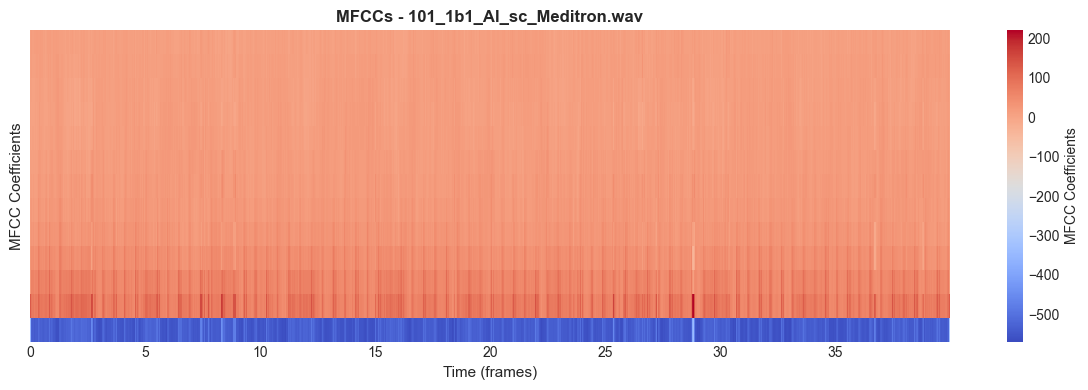

In [14]:
# Function to extract MFCCs
def extract_mfcc(file_path, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfccs

# %%
# Extract MFCCs for a sample file
if audio_files:
    sample_file = audio_files[0]
    mfccs = extract_mfcc(sample_file)
    
    print(f"MFCC shape for {sample_file.name}:")
    print(f"  - {mfccs.shape[0]} MFCC coefficients")
    print(f"  - {mfccs.shape[1]} time frames")
    
    # Plot MFCCs
    plt.figure(figsize=(12, 4))
    librosa.display.specshow(mfccs, x_axis='time', cmap='coolwarm')
    plt.colorbar(label='MFCC Coefficients')
    plt.title(f'MFCCs - {sample_file.name}', fontsize=12, fontweight='bold')
    plt.xlabel('Time (frames)', fontsize=11)
    plt.ylabel('MFCC Coefficients', fontsize=11)
    plt.tight_layout()
    plt.show()

## 10. Summary Statistics

In [15]:
# Create summary dataframe
summary = pd.DataFrame({
    'Metric': [
        'Total Audio Files',
        'Total Annotation Files',
        'Paired Files (wav+txt)',
        'Unique Patients',
        'Chest Locations',
        'Average Duration',
        'Duration Range',
        'Sample Rate'
    ],
    'Value': [
        len(audio_files),
        len(annotation_files),
        f"{len(common_names)} ({len(common_names)/len(audio_files)*100:.1f}%)",
        df_files['patient_id'].nunique() if 'patient_id' in df_files.columns else 'N/A',
        df_files['chest_location'].nunique() if 'chest_location' in df_files.columns else 'N/A',
        f"{df_audio_stats['duration'].mean():.2f} s" if len(df_audio_stats) > 0 else 'N/A',
        f"{df_audio_stats['duration'].min():.2f} - {df_audio_stats['duration'].max():.2f} s" if len(df_audio_stats) > 0 else 'N/A',
        '4000 Hz (typical)'
    ]
})

summary

,Metric,Value
0,Total Audio Files,920
1,Total Annotation Files,922
2,Paired Files (wav+txt),920 (100.0%)
3,Unique Patients,126
4,Chest Locations,7
5,Average Duration,24.52 s
6,Duration Range,12.46 - 86.20 s
7,Sample Rate,4000 Hz (typical)


 ## 11. Key Findings Summary

In [17]:
# %%
print("="*60)
print("🔍 ICBHI 2017 DATASET - KEY FINDINGS")
print("="*60)
print(f"1. 📊 Total Recordings: {len(audio_files)}")
print(f"2. 📝 Total Annotations: {len(annotation_files)}")
print(f"3. ✅ Paired Files: {len(common_names)} ({len(common_names)/len(audio_files)*100:.1f}% of audio files)")
print(f"4. 👶 Unique Patients: {df_files['patient_id'].nunique()}")
print(f"5. 📏 Average Duration: {df_audio_stats['duration'].mean():.2f} seconds")
print(f"6. 📈 Duration Range: {df_audio_stats['duration'].min():.2f} - {df_audio_stats['duration'].max():.2f} seconds")
print(f"7. 🎚️ Chest Locations: {df_files['chest_location'].nunique()} different positions")
print(f"8. 🔥 Most Common Location: {df_files['chest_location'].mode().values[0]}")
print(f"9. 🎵 MFCC Features: 13 coefficients per time frame")
print("="*60)

# Save summary to CSV
df_files.to_csv(ICBHI_PATH / "icbhi_file_list.csv", index=False)
print(f"\n✅ Saved file list to: {ICBHI_PATH}/icbhi_file_list.csv")

🔍 ICBHI 2017 DATASET - KEY FINDINGS
1. 📊 Total Recordings: 920
2. 📝 Total Annotations: 922
3. ✅ Paired Files: 920 (100.0% of audio files)
4. 👶 Unique Patients: 126
5. 📏 Average Duration: 24.52 seconds
6. 📈 Duration Range: 12.46 - 86.20 seconds
7. 🎚️ Chest Locations: 7 different positions
8. 🔥 Most Common Location: Ar
9. 🎵 MFCC Features: 13 coefficients per time frame

✅ Saved file list to: ..\sound_data\icbhi/icbhi_file_list.csv
